# sim_crosstalk notebook

基于 `sim_crosstalk.py` helper 的端到端复现 notebook。

这个 notebook 不再直接调用 `main()`，而是逐步执行完整流程：
- 读取 `Y40178MC.gem` 和 `Y40178P5.gem`
- 生成 `mixed.gem`
- 将 MC / P5 / mixed 转换为 `*.gef`
- 为 `Y40178MC`、`Y40178P5`、`mixed` 分别准备 CellBin2 config 并执行 CellBin2
- 从最终 `*_cell_mask.tif` 提取细胞元数据
- 为 GEM 分子分配 cell label
- 对 mixed 细胞做基于 mask 的映射，并筛选重叠双胞/多胞目标
- 写出 `mixed_maped.h5ad`，其中 `X` 为 mixed 目标细胞表达，`layers["source"]` 为覆盖比例最高的映射源细胞完整表达


In [35]:
from pathlib import Path
import importlib
import json

import anndata as ad
from IPython.display import Image, display
import pandas as pd

import sim_crosstalk
sim_crosstalk = importlib.reload(sim_crosstalk)


In [36]:
repo_root = Path.cwd().resolve()
mc_gem = (repo_root / "data/Y40178MC/Y40178MC.gem").resolve()
p5_gem = (repo_root / "data/Y40178P5/Y40178P5.gem").resolve()
output_dir = (repo_root / "outputs/sim_crosstalk").resolve()
cellbin2_template = (repo_root / "cellbin2/config/demos/Stereocell_analysis.json").resolve()
cellbin2_entry = (repo_root / "cellbin2/cellbin_pipeline.py").resolve()
cellbin2_python = Path(sim_crosstalk.DEFAULT_CELLBIN2_PYTHON).resolve()
chunk_size = 1_000_000
min_mixed_coverage = 0.1
force_rerun = False

configs_dir = (output_dir / "configs").resolve()
runs_dir = (output_dir / "cellbin2").resolve()
mixed_gem_path = (output_dir / "mixed.gem").resolve()
mc_gef_path = (output_dir / "Y40178MC.gef").resolve()
p5_gef_path = (output_dir / "Y40178P5.gef").resolve()
mixed_gef_path = (output_dir / "mixed.gef").resolve()
mixed_maped_h5ad_path = (output_dir / "mixed_maped.h5ad").resolve()
spatial_tile_path = (output_dir / "spatial_tile_r10_c10.png").resolve()

for path in [repo_root, mc_gem, p5_gem, cellbin2_template, cellbin2_entry, cellbin2_python]:
    print(path, path.exists())


/usr/commondata/public/zhaoyeping/projects/cellbin2 True
/usr/commondata/public/zhaoyeping/data/stereo-cell/Y40178MC/Y40178MC.gem True
/usr/commondata/public/zhaoyeping/data/stereo-cell/Y40178P5/Y40178P5.gem True
/usr/commondata/public/zhaoyeping/projects/cellbin2/cellbin2/config/demos/Stereocell_analysis.json True
/usr/commondata/public/zhaoyeping/projects/cellbin2/cellbin2/cellbin_pipeline.py True
/opt/miniforge3/envs/env-cellbinv2/bin/python3.8 True


## 1. 准备输出目录


In [37]:
sim_crosstalk.ensure_output_dir(output_dir, force=force_rerun)
configs_dir.mkdir(parents=True, exist_ok=True)
runs_dir.mkdir(parents=True, exist_ok=True)
print("force_rerun=", force_rerun)
print("output_dir=", output_dir)


force_rerun= False
output_dir= /usr/commondata/public/zhaoyeping/projects/cellbin2/outputs/sim_crosstalk


## 2. 生成 mixed.gem


In [38]:
if force_rerun or not mixed_gem_path.exists():
    mixed_summary = sim_crosstalk.build_mixed_gem(
        mc_gem=mc_gem,
        p5_gem=p5_gem,
        output_path=mixed_gem_path,
        chunk_size=chunk_size,
    )
else:
    mixed_summary = {
        "mixed_row_count": sum(len(chunk) for chunk in sim_crosstalk.iter_gem_chunks(mixed_gem_path, chunk_size)),
        "mixed_mid_total": sum(int(chunk["MIDCount"].sum()) for chunk in sim_crosstalk.iter_gem_chunks(mixed_gem_path, chunk_size)),
    }

if force_rerun or not mc_gef_path.exists():
    sim_crosstalk.convert_gem_to_gef(mc_gem, mc_gef_path)
if force_rerun or not p5_gef_path.exists():
    sim_crosstalk.convert_gem_to_gef(p5_gem, p5_gef_path)
if force_rerun or not mixed_gef_path.exists():
    sim_crosstalk.convert_gem_to_gef(mixed_gem_path, mixed_gef_path)

for path in [mixed_gem_path, mc_gef_path, p5_gef_path, mixed_gef_path]:
    print(path, path.exists())
mixed_summary


/usr/commondata/public/zhaoyeping/projects/cellbin2/outputs/sim_crosstalk/mixed.gem True
/usr/commondata/public/zhaoyeping/projects/cellbin2/outputs/sim_crosstalk/Y40178MC.gef True
/usr/commondata/public/zhaoyeping/projects/cellbin2/outputs/sim_crosstalk/Y40178P5.gef True
/usr/commondata/public/zhaoyeping/projects/cellbin2/outputs/sim_crosstalk/mixed.gef True


{'mixed_row_count': 312915032, 'mixed_mid_total': 364279694}

## 3. 为三个样本准备 CellBin2 config


In [39]:
if not mixed_gem_path.exists():
    raise FileNotFoundError(f"missing mixed.gem: {mixed_gem_path}")
if not mc_gef_path.exists():
    sim_crosstalk.convert_gem_to_gef(mc_gem, mc_gef_path)
if not p5_gef_path.exists():
    sim_crosstalk.convert_gem_to_gef(p5_gem, p5_gef_path)
if not mixed_gef_path.exists():
    sim_crosstalk.convert_gem_to_gef(mixed_gem_path, mixed_gef_path)

sample_defs = {
    "Y40178MC": mc_gef_path,
    "Y40178P5": p5_gef_path,
    "mixed": mixed_gef_path,
}
config_paths = {}
for sample_name, gem_path in sample_defs.items():
    config_paths[sample_name] = sim_crosstalk.prepare_cellbin2_config(
        sample_name=sample_name,
        gem_path=gem_path,
        template_path=cellbin2_template,
        config_path=(configs_dir / f"{sample_name}.json").resolve(),
    )
config_paths


{'Y40178MC': PosixPath('/usr/commondata/public/zhaoyeping/projects/cellbin2/outputs/sim_crosstalk/configs/Y40178MC.json'),
 'Y40178P5': PosixPath('/usr/commondata/public/zhaoyeping/projects/cellbin2/outputs/sim_crosstalk/configs/Y40178P5.json'),
 'mixed': PosixPath('/usr/commondata/public/zhaoyeping/projects/cellbin2/outputs/sim_crosstalk/configs/mixed.json')}

## 4.1 检查 `LD_LIBRARY_PATH` 注入结果


In [40]:
cellbin2_env = sim_crosstalk.build_cellbin2_env()
ld_library_path = cellbin2_env.get("LD_LIBRARY_PATH", "")
ld_entries = [entry for entry in ld_library_path.split(":") if entry]

print("LD_LIBRARY_PATH entries:", len(ld_entries))
print("first entries:")
for entry in ld_entries[:8]:
    print(" -", entry)

print("contains cudnn:", any("nvidia/cudnn/lib" in entry for entry in ld_entries))
print("contains cublas:", any("nvidia/cublas/lib" in entry for entry in ld_entries))


LD_LIBRARY_PATH entries: 12
first entries:
 - /opt/miniforge3/envs/env-cellbinv2/lib/python3.8/site-packages/nvidia/cudnn/lib
 - /opt/miniforge3/envs/env-cellbinv2/lib/python3.8/site-packages/nvidia/cublas/lib
 - /opt/miniforge3/envs/env-cellbinv2/lib/python3.8/site-packages/nvidia/cuda_runtime/lib
 - /opt/miniforge3/envs/env-cellbinv2/lib/python3.8/site-packages/nvidia/cuda_nvrtc/lib
 - /opt/miniforge3/envs/env-cellbinv2/lib/python3.8/site-packages/nvidia/cufft/lib
 - /opt/miniforge3/envs/env-cellbinv2/lib/python3.8/site-packages/nvidia/curand/lib
 - /opt/miniforge3/envs/env-cellbinv2/lib/python3.8/site-packages/nvidia/cusolver/lib
 - /opt/miniforge3/envs/env-cellbinv2/lib/python3.8/site-packages/nvidia/cusparse/lib
contains cudnn: True
contains cublas: True


## 4. 分别执行 CellBin2


In [41]:
run_outputs = {}
for sample_name, config_path in config_paths.items():
    run_dir = runs_dir / sample_name
    cell_mask_path = run_dir / f"{sample_name}_cell_mask.tif"
    if sample_name not in run_outputs and not force_rerun and cell_mask_path.exists():
        run_outputs[sample_name] = sim_crosstalk.get_run_output(sample_name, run_dir)
    else:
        run_outputs[sample_name] = sim_crosstalk.run_cellbin2(
            sample_name=sample_name,
            config_path=config_path,
            run_output_dir=run_dir,
            cellbin2_python=cellbin2_python,
            cellbin2_entry=cellbin2_entry,
        )
run_outputs


{'Y40178MC': {'cell_mask': '/usr/commondata/public/zhaoyeping/projects/cellbin2/outputs/sim_crosstalk/cellbin2/Y40178MC/Y40178MC_cell_mask.tif',
  'returncode': 'existing'},
 'Y40178P5': {'cell_mask': '/usr/commondata/public/zhaoyeping/projects/cellbin2/outputs/sim_crosstalk/cellbin2/Y40178P5/Y40178P5_cell_mask.tif',
  'returncode': 'existing'},
 'mixed': {'cell_mask': '/usr/commondata/public/zhaoyeping/projects/cellbin2/outputs/sim_crosstalk/cellbin2/mixed/mixed_cell_mask.tif',
  'returncode': 'existing'}}

## 5. 读取最终 cell mask 并提取 cell metadata


In [42]:
mc_labels = sim_crosstalk.load_final_cell_labels(Path(run_outputs["Y40178MC"]["cell_mask"]))
p5_labels = sim_crosstalk.load_final_cell_labels(Path(run_outputs["Y40178P5"]["cell_mask"]))
mixed_labels = sim_crosstalk.load_final_cell_labels(Path(run_outputs["mixed"]["cell_mask"]))

mc_cells = sim_crosstalk.extract_cell_metadata(mc_labels, "MC")
p5_cells = sim_crosstalk.extract_cell_metadata(p5_labels, "P5")
mixed_cells = sim_crosstalk.extract_cell_metadata(mixed_labels, "mixed")

print("mc cells", len(mc_cells))
print("p5 cells", len(p5_cells))
print("mixed cells", len(mixed_cells))
mixed_cells.head()


mc cells 10151
p5 cells 8728
mixed cells 16308


,cell_label,source,pixel_label,area,bbox_min_x,bbox_min_y,bbox_max_x,bbox_max_y,centroid_x,centroid_y
0,mixed_1,mixed,1,2471,0,0,19,210,5.545123,99.182113
1,mixed_2,mixed,2,245,101,0,124,11,112.775510,4.808163
2,mixed_3,mixed,3,252,161,0,182,12,171.500000,5.388889
3,mixed_4,mixed,4,296,211,0,238,11,224.280405,4.979730
4,mixed_5,mixed,5,230,281,0,302,11,291.500000,4.904348


## 6. 为三个 GEM 分配 molecules-to-cells


In [43]:
mc_molecules = sim_crosstalk.assign_molecules_to_cells(mc_gem, mc_labels, "MC", chunk_size)
p5_molecules = sim_crosstalk.assign_molecules_to_cells(p5_gem, p5_labels, "P5", chunk_size)
mixed_molecules = sim_crosstalk.assign_molecules_to_cells(mixed_gem_path, mixed_labels, "mixed", chunk_size)

print("mc molecule rows", len(mc_molecules))
print("p5 molecule rows", len(p5_molecules))
print("mixed molecule rows", len(mixed_molecules))
mixed_molecules.head()


mc molecule rows 93074859
p5 molecule rows 81884616
mixed molecule rows 185230506


,geneID,x,y,MIDCount,ExonCount,cell_label,pixel_label,source
0,TSPAN6,4213,8981,1,0,mixed_5853,5853,mixed
1,TSPAN6,4957,10991,1,1,mixed_8099,8099,mixed
2,TSPAN6,6952,4907,1,0,mixed_1748,1748,mixed
3,TSPAN6,7057,10818,1,1,mixed_7889,7889,mixed
4,TSPAN6,7169,6460,1,1,mixed_3216,3216,mixed


## 7. 对 mixed 细胞做 mask 映射与双细胞判定


In [44]:
candidates_df, mapping_df = sim_crosstalk.map_mixed_cells(
    mixed_cells=mixed_cells,
    mc_cells=mc_cells,
    p5_cells=p5_cells,
    mixed_labels=mixed_labels,
    mc_labels=mc_labels,
    p5_labels=p5_labels,
    min_mixed_coverage=min_mixed_coverage,
)

multiplet_df = mapping_df.loc[mapping_df["is_multiplet"]].copy()
print("mapping rows", len(mapping_df))
print("mapped rows", int(mapping_df["mapped_source_count"].gt(0).sum()))
print("multiplet target rows", len(multiplet_df))
mapping_df.head()


mapping rows 16308
mapped rows 16160
multiplet target rows 3497


,mixed_cell_label,mapped_source_dataset,mapped_source_label,mapped_source_datasets,mapped_source_labels,mapped_source_count,mapped_mixed_coverage,mapped_overlap_pixels,is_doublet,is_multiplet,doublet_reason
0,mixed_1,MC,MC_439,MC;P5,MC_439;P5_181;MC_1;P5_1,4,0.472278,1167,True,True,multi_source_mask_overlap
1,mixed_2,MC,MC_2,MC,MC_2,1,0.175510,43,False,False,
2,mixed_3,P5,P5_2,MC;P5,P5_2;MC_3,2,0.948413,239,True,True,multi_source_mask_overlap
3,mixed_4,P5,P5_3,P5,P5_3,1,0.837838,248,False,False,
4,mixed_5,MC,MC_5,MC,MC_5,1,1.000000,230,False,False,


## 8. 筛选 mixed 重叠双胞/多胞目标并写出输出


In [45]:
target_molecules = sim_crosstalk.select_multiplet_molecules(mixed_molecules, mapping_df)
sim_crosstalk.write_mixed_molecule_outputs(
    molecules=target_molecules,
    output_gem=output_dir / "mixed_multiplet.gem",
    output_parquet=output_dir / "mixed_multiplet_molecules.parquet",
    header_lines=sim_crosstalk.read_gem_header(mc_gem),
)
print("target molecule rows", len(target_molecules))
target_molecules.head()


target molecule rows 52626448


,geneID,x,y,MIDCount,ExonCount,cell_label,pixel_label,source
6,TSPAN6,7790,15057,1,0,mixed_12540,12540,mixed
9,TSPAN6,8871,3809,1,1,mixed_909,909,mixed
11,TSPAN6,9387,8742,1,0,mixed_5598,5598,mixed
13,TSPAN6,9468,8724,1,0,mixed_5562,5562,mixed
18,TSPAN6,10582,9894,2,2,mixed_6875,6875,mixed


## 9. 构建并写出 `mixed_maped.h5ad`

这里只保留映射到两个或更多 source cells 的 mixed 目标细胞。`adata.X` 为 mixed 目标细胞表达，`adata.layers["source"]` 为每个 mixed cell 映射回的覆盖比例最高 MC/P5 source cell 完整表达。


In [46]:
obs_df, gene_order, mixed_x, source_x = sim_crosstalk.build_mapped_h5ad_inputs(
    mixed_cells=mixed_cells,
    target_molecules=target_molecules,
    mapping_df=mapping_df,
    mc_molecules=mc_molecules,
    p5_molecules=p5_molecules,
)
mixed_maped_h5ad_path = (output_dir / "mixed_maped.h5ad").resolve()
sim_crosstalk.write_mixed_mapped_h5ad(
    mixed_maped_h5ad_path,
    obs_df=obs_df,
    gene_order=gene_order,
    mixed_x=mixed_x,
    source_x=source_x,
)
print(mixed_maped_h5ad_path, mixed_maped_h5ad_path.exists())
print("mixed_x shape", mixed_x.shape)
print("source_x shape", source_x.shape)


/usr/commondata/public/zhaoyeping/projects/cellbin2/outputs/sim_crosstalk/mixed_maped.h5ad True
mixed_x shape (3497, 29148)
source_x shape (3497, 29148)


## 10. 空间可视化

mixed 相关面板使用 mixed 芯片第 `(10, 10)` 块；MC / P5 原始面板使用各自芯片第 `(10, 10)` 块；`multiplet source` 面板使用与 mixed tile 相同窗口显示目标 mixed cells 映射到的 source cells，便于比较重叠双胞/多胞目标与来源细胞。


/usr/commondata/public/zhaoyeping/projects/cellbin2/outputs/sim_crosstalk/spatial_tile_r10_c10.png True


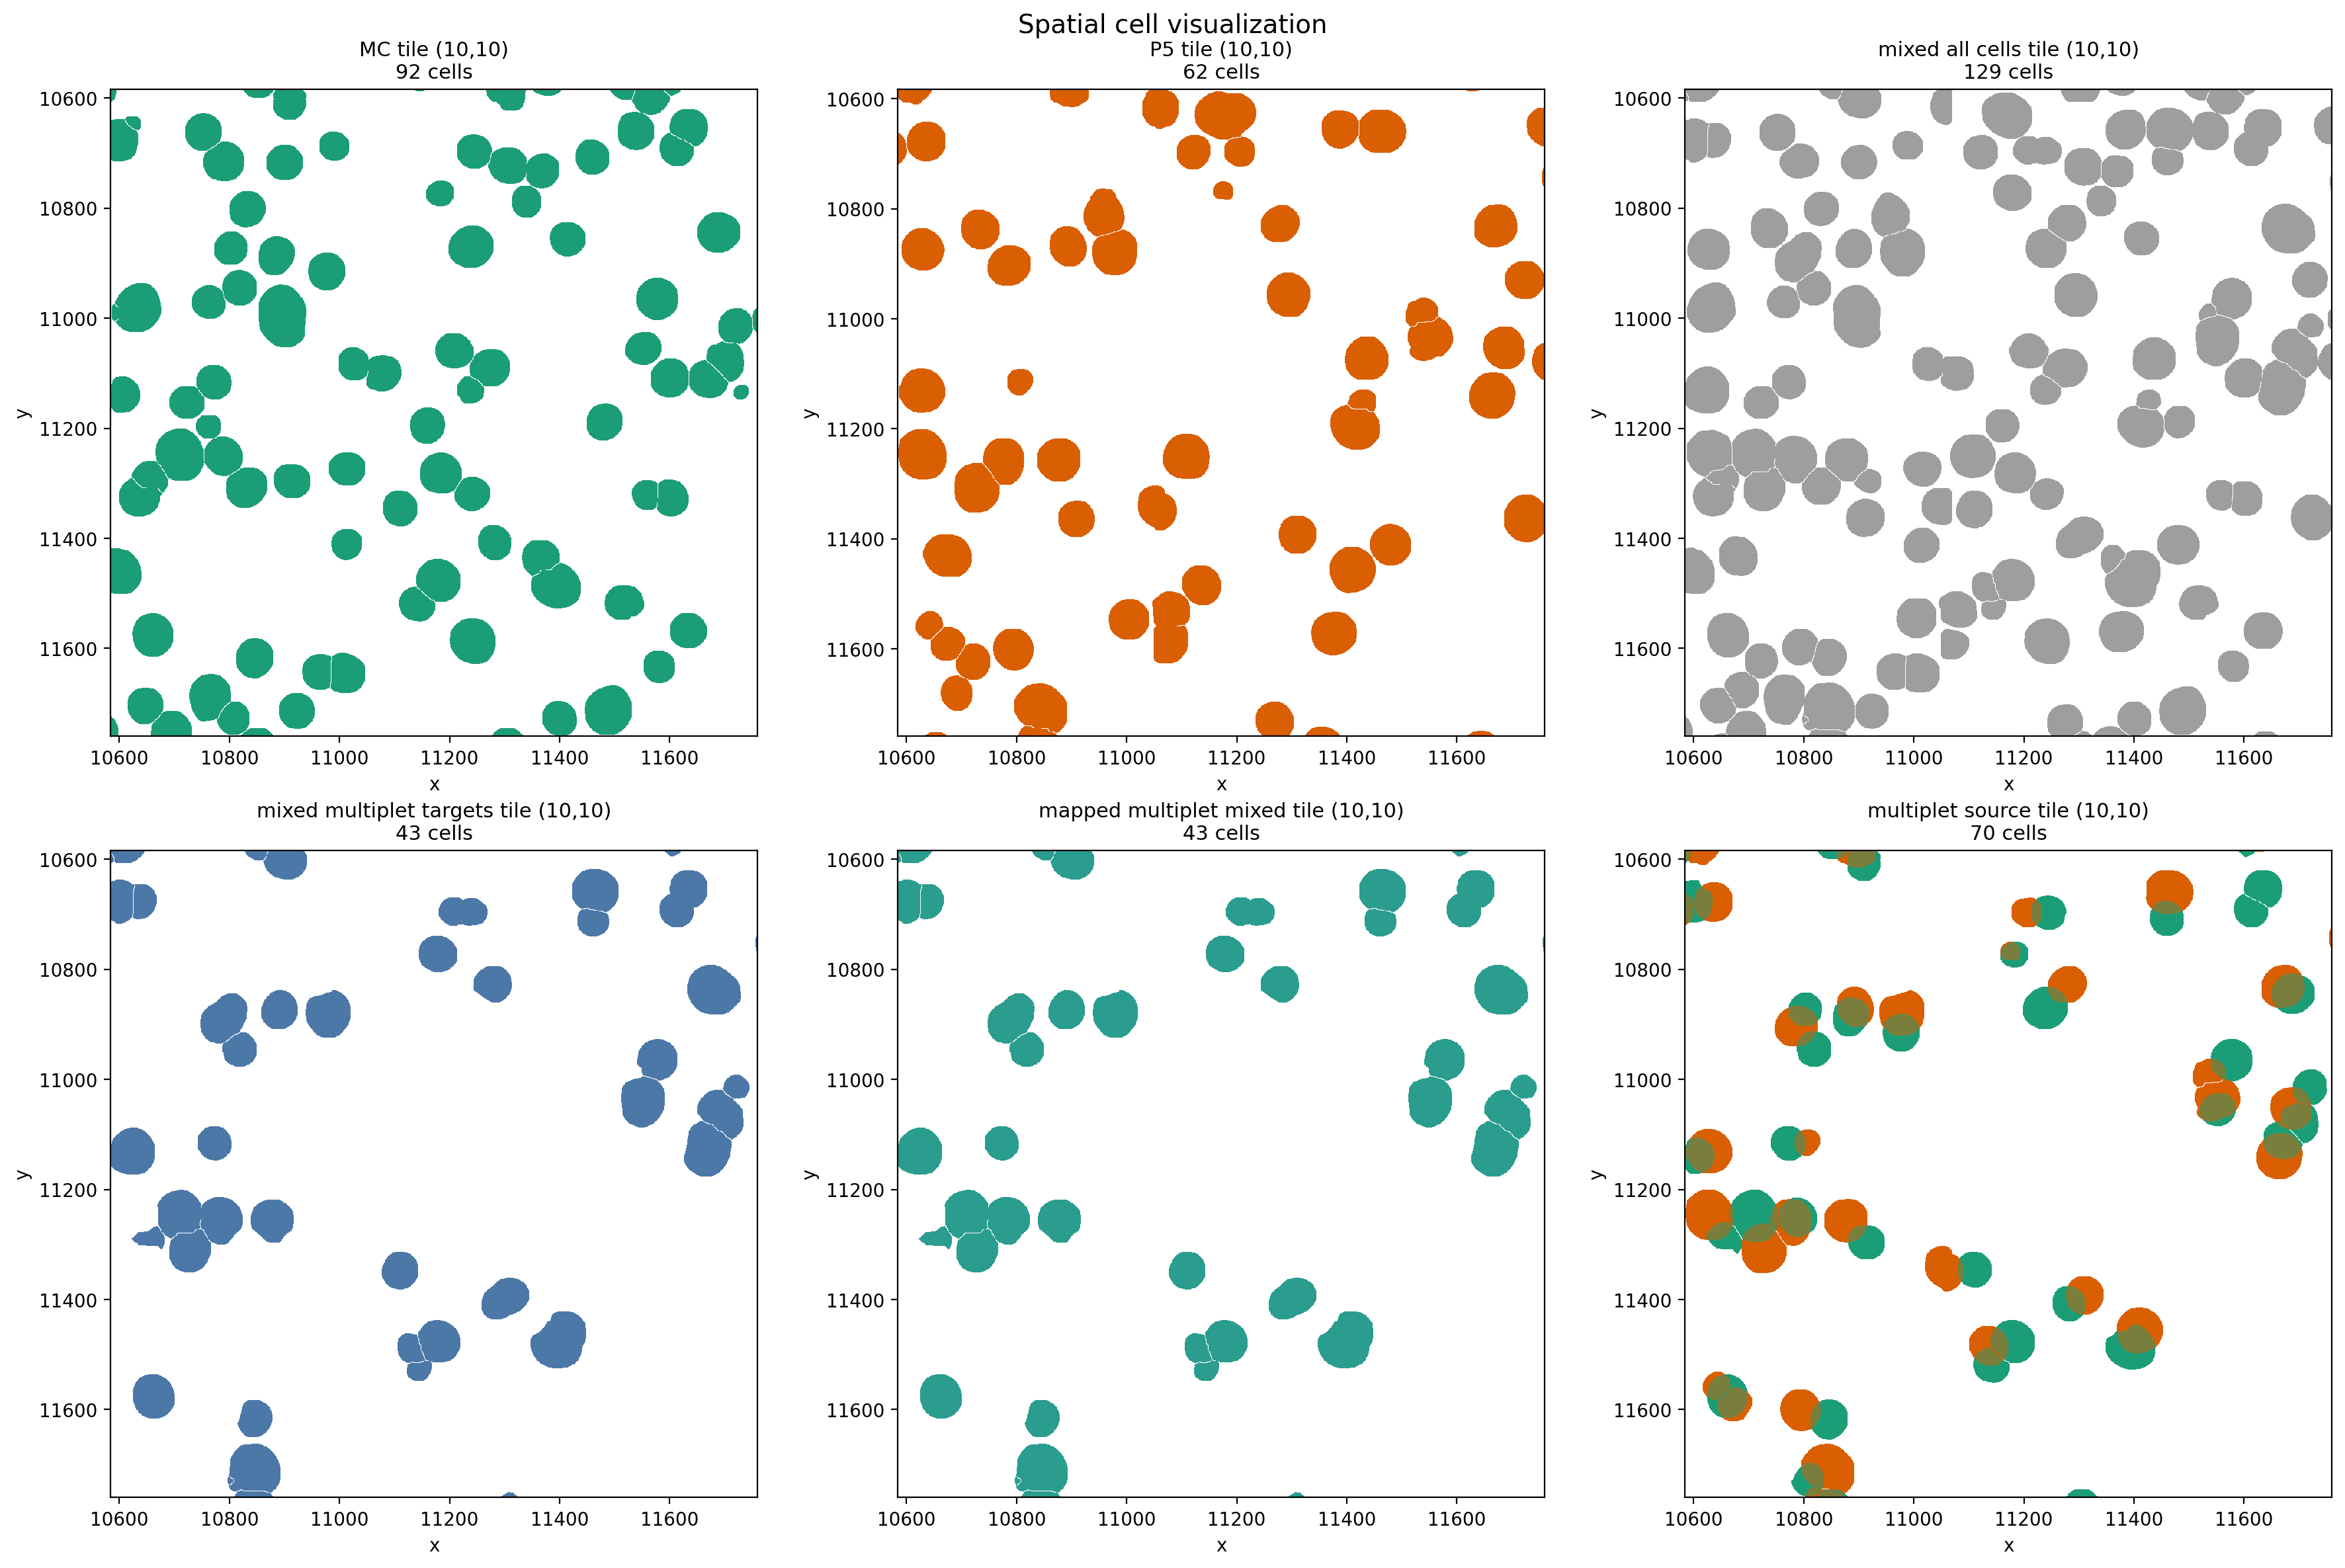

In [47]:
sim_crosstalk.write_spatial_visualization(
    output_path=spatial_tile_path,
    mc_cells=mc_cells,
    p5_cells=p5_cells,
    mixed_cells=mixed_cells,
    mapping_df=mapping_df,
    mc_labels=mc_labels,
    p5_labels=p5_labels,
    mixed_labels=mixed_labels,
)
print(spatial_tile_path, spatial_tile_path.exists())
display(Image(filename=str(spatial_tile_path)))


## 11. 保存中间表和 summary


In [48]:
mc_cells.to_parquet(output_dir / "mc_cells.parquet", index=False)
p5_cells.to_parquet(output_dir / "p5_cells.parquet", index=False)
mixed_cells.to_parquet(output_dir / "mixed_cells.parquet", index=False)
mc_molecules.to_parquet(output_dir / "mc_molecules.parquet", index=False)
p5_molecules.to_parquet(output_dir / "p5_molecules.parquet", index=False)
mixed_molecules.to_parquet(output_dir / "mixed_molecules.parquet", index=False)
candidates_df.to_parquet(output_dir / "mixed_mask_overlap_candidates.parquet", index=False)
mapping_df.to_parquet(output_dir / "mixed_cell_mapping.parquet", index=False)
multiplet_df.to_parquet(output_dir / "mixed_multiplet_mapping.parquet", index=False)

mc_rows = sum(len(chunk) for chunk in sim_crosstalk.iter_gem_chunks(mc_gem, chunk_size))
p5_rows = sum(len(chunk) for chunk in sim_crosstalk.iter_gem_chunks(p5_gem, chunk_size))

sim_crosstalk.write_summary(
    output_dir / "summary.json",
    mc_rows=mc_rows,
    p5_rows=p5_rows,
    mixed_summary=mixed_summary,
    mc_cells=mc_cells,
    p5_cells=p5_cells,
    mixed_cells=mixed_cells,
    mapping_df=mapping_df,
    target_molecules=target_molecules,
    run_outputs=run_outputs,
)


## 12. 查看 summary、最终目标表与 `mixed_maped.h5ad`


In [49]:
summary = json.loads((output_dir / "summary.json").read_text(encoding="utf-8"))
raw_mixed = pd.read_csv(output_dir / "mixed.gem", sep="	", comment="#")
target_mixed = pd.read_csv(output_dir / "mixed_multiplet.gem", sep="	", comment="#")
mixed_maped = ad.read_h5ad(mixed_maped_h5ad_path)

print("raw mixed rows", len(raw_mixed))
print("target mixed rows", len(target_mixed))
print("mixed_maped shape", mixed_maped.shape)
print("layers", list(mixed_maped.layers.keys()))
mixed_maped.obs.head()


raw mixed rows 312915032
target mixed rows 52626448
mixed_maped shape (3497, 29148)
layers ['source']


,mixed_cell_label,mapped_source_dataset,mapped_source_label,mapped_source_datasets,mapped_source_labels,mapped_source_count,mapped_mixed_coverage,mapped_overlap_pixels,is_multiplet,is_doublet,doublet_reason
mixed_cell_label,,,,,,,,,,,
mixed_1,mixed_1,MC,MC_439,MC;P5,MC_439;P5_181;MC_1;P5_1,4,0.472278,1167,True,True,multi_source_mask_overlap
mixed_3,mixed_3,P5,P5_2,MC;P5,P5_2;MC_3,2,0.948413,239,True,True,multi_source_mask_overlap
mixed_8,mixed_8,P5,P5_5,MC;P5,P5_5;MC_8;P5_6,3,0.692661,151,True,True,multi_source_mask_overlap
mixed_12,mixed_12,MC,MC_12,MC;P5,MC_12;P5_11,2,0.782278,309,True,True,multi_source_mask_overlap
mixed_13,mixed_13,MC,MC_13,MC;P5,MC_13;P5_12,2,0.883197,431,True,True,multi_source_mask_overlap
